# Residual Diagnostics in Compton Data Space
***

This notebook develops and validates residual diagnostics for binned COSI analyses. It begins with the 511 keV fitted products generated in the previous analyses, comparing observed counts with the fitted source-plus-background expectation in the same multidimensional Compton Data Space. Raw and Pearson residuals will be investigated as functions of the available coordinates before the validated procedure is generalized into a reusable module.

***
## Setup

In [1]:
%load_ext autoreload
%autoreload 2

# Handle filesystem paths in a platform-independent way.
from pathlib import Path
import sys # Access the Python import path.

working_dir = Path.cwd()
repo_root = (
    working_dir.parent
    if working_dir.name == "notebooks"
    else working_dir
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import numpy as np
import pandas as pd
from histpy import Histogram 
import astropy.units as u
import mhealpy as mhp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from astropy.coordinates import SkyCoord
from scipy import stats
# Inspect the internal structure of HDF5 files.
import h5py

%matplotlib inline

***
## Load & validate data

### Load

In [3]:
# Residual products generated by the imaging and parametric analyses.
residual_dir = repo_root / "data" / "residual"

disk_scale_file = residual_dir / "04_511_disk_scale_residual_products.hdf5"

print("Disk-scale products:", disk_scale_file)

Disk-scale products: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/residual/04_511_disk_scale_residual_products.hdf5


In [4]:
# List the products stored in the HDF5 file.
with h5py.File(disk_scale_file, "r") as residual_file:
    product_names = list(residual_file.keys())

print("Available products:", product_names)

Available products: ['background_expectation', 'observed', 'source_expectation', 'total_expectation']


In [5]:
# Load the data from the HDF5 file into Histogram objects for analysis.
observed_disk_scale = Histogram.open(
    disk_scale_file,
    name = "observed")

source_disk_scale = Histogram.open(
    disk_scale_file,
    name = "source_expectation")

background_disk_scale = Histogram.open(
    disk_scale_file,    
    name = "background_expectation")

expected_disk_scale = Histogram.open(
    disk_scale_file,
    name = "total_expectation")

# keep the complete histograms organised in one collection
disk_scale_products = {
    "observed": observed_disk_scale,
    "source": source_disk_scale,
    "background": background_disk_scale,
    "expected": expected_disk_scale
}

### Validation

In [6]:
# Use the observed histogram as the reference data space.
reference_axes = observed_disk_scale.axes

for product_name, histogram in disk_scale_products.items():
    if histogram.axes != reference_axes:
        raise ValueError(
            f"{product_name} has incompatible axes."
        )

    print(
        product_name,
        histogram.axes.labels,
        histogram.shape,
    )

observed ['Em' 'Phi' 'PsiChi'] (1, 60, 3072)
source ['Em' 'Phi' 'PsiChi'] (1, 60, 3072)
background ['Em' 'Phi' 'PsiChi'] (1, 60, 3072)
expected ['Em' 'Phi' 'PsiChi'] (1, 60, 3072)


In [7]:
# Verify that the total expectation equals the sum of its components.
component_sum = (
    source_disk_scale.contents
    + background_disk_scale.contents
)

if not np.allclose(
    expected_disk_scale.contents,
    component_sum,
    rtol=1e-12,
    atol=1e-12,
):
    raise ValueError(
        "The total expectation does not match "
        "source plus background."
    )

print("Expected = source + background.")

Expected = source + background.


In [8]:
# Validate the numerical contents of every data product.

# Build a summary table for the validated data products.
summary_rows = []

for product_name, histogram in disk_scale_products.items():
    values = np.asarray(
        histogram.contents,
        dtype=float,
        copy=True)

    if not np.all(np.isfinite(values)):
        raise ValueError(
            f"{product_name} contains non-finite values."
        )

    if np.any(values < 0):
        raise ValueError(
            f"{product_name} contains negative values."
        )
# Summary for each product.
    summary_rows.append(
        {
            "Product": product_name,
            "Axes": ", ".join(histogram.axes.labels),
            "Shape": str(histogram.shape),
            "Total counts": values.sum(),
            "Minimum": values.min(),
            "Maximum": values.max(),
            "Nonzero bins": np.count_nonzero(values),
        }
    )

disk_scale_summary = pd.DataFrame(summary_rows)


print("All products contain finite, non-negative values.")
disk_scale_summary

All products contain finite, non-negative values.


,Product,Axes,Shape,Total counts,Minimum,Maximum,Nonzero bins
0,observed,"Em, Phi, PsiChi","(1, 60, 3072)",1.576953e+06,0.000000e+00,39.000000,163028
1,source,"Em, Phi, PsiChi","(1, 60, 3072)",1.842110e+05,0.000000e+00,11.758953,175104
2,background,"Em, Phi, PsiChi","(1, 60, 3072)",1.392745e+06,2.253815e-308,33.426255,184320
3,expected,"Em, Phi, PsiChi","(1, 60, 3072)",1.576956e+06,2.253815e-308,37.236930,184320


***
## Explore the data structure

This section examines the dimensions and coordinate system of the validated COSI data products before any projection or residual statistic is defined. The observed counts and the fitted source, background, and total expectations remain as multidimensional `Histogram` objects in the original `Em`, `Phi`, and `PsiChi` data space.

The objective here is only to identify the available axes, binning, and HEALPix geometry. Data projections are prepared in the following section.

### Available data dimensions

In [9]:
# Summarize the dimensions available for projections.
axis_summary = pd.DataFrame(
    {
        "Axis": list(observed_disk_scale.axes.labels),
        "Type": [
            type(axis).__name__
            for axis in observed_disk_scale.axes
        ],
        "Bins": observed_disk_scale.shape,
        "Unit": [
            str(getattr(axis, "unit", ""))
            for axis in observed_disk_scale.axes
        ],
    }
)

axis_summary

,Axis,Type,Bins,Unit
0,Em,Axis,1,keV
1,Phi,Axis,60,deg
2,PsiChi,HealpixAxis,3072,None


In [10]:
# Inspect the HEALPix geometry of the PsiChi axis.
psichi_axis = observed_disk_scale.axes["PsiChi"]

print("Coordinate system:", psichi_axis.coordsys)
print("NSIDE:", psichi_axis.nside)
print("Scheme:", psichi_axis.scheme)
print("Number of pixels:", psichi_axis.nbins)

Coordinate system: <Galactic Frame>
NSIDE: 16
Scheme: RING
Number of pixels: 3072


***
## Prepare matched data projections

All data products must be projected onto the same axes before they are compared. The helper below applies an identical projection to the observed counts and every fitted-model component while preserving the histogram axes and metadata.

### Projection function

In [11]:
def project_data_products(products, *axis_names):
    """
    Project a collection of compatible histograms onto the same axes.
    """
    if not axis_names:
        raise ValueError(
            "Provide at least one axis for the projection."
        )

    reference_histogram = products["observed"]
    available_axes = set(reference_histogram.axes.labels)
    unknown_axes = set(axis_names) - available_axes

    if unknown_axes:
        raise ValueError(
            f"Unknown projection axes: {sorted(unknown_axes)}"
        )

    projected_products = {
        product_name: histogram.project(*axis_names)
        for product_name, histogram in products.items()
    }

    return projected_products

In [12]:
def plot_raw_residual_projection(
    coordinates,
    observed,
    expected,
    residual,
    x_label,
    title,
):
    """Plot projected counts and their raw residual."""
    figure, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(10, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    counts_axis, residual_axis = axes

    # Compare the projected observed and expected counts.
    counts_axis.step(
        coordinates,
        observed,
        where="mid",
        color="black",
        linewidth=1.5,
        label="Observed",
    )

    counts_axis.step(
        coordinates,
        expected,
        where="mid",
        color="red",
        linewidth=1.5,
        linestyle=":",
        label="Fitted expectation",
    )

    counts_axis.set_ylabel("Counts")
    counts_axis.set_title(title)
    counts_axis.legend()
    counts_axis.grid(alpha=0.2)

    # Show the corresponding raw residual.
    residual_axis.scatter(
        coordinates,
        residual,
        color="tab:purple",
        s=25,
    )

    residual_axis.axhline(
        0.0,
        color="black",
        linewidth=1,
        linestyle="--",
    )

    residual_axis.set_xlabel(x_label)
    residual_axis.set_ylabel("Raw residual")
    residual_axis.grid(alpha=0.2)

    figure.tight_layout()
    plt.show()

In [34]:
def plot_raw_residual_heatmap(
    axis,
    x_edges,
    y_edges,
    residual,
    x_label,
    y_label,
    title,
    color_norm,
):
    """Plot a two-dimensional raw-residual heatmap."""
    image = axis.pcolormesh(
        x_edges,
        y_edges,
        residual,
        cmap="RdBu_r",
        norm=color_norm,
        shading="auto",
    )

    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_title(title)

    return image

In [13]:
# Project every data product onto the Phi axis.
phi_products = project_data_products(
    disk_scale_products,
    "Phi",
)

# Display the axes and shape of each projected histogram.
for product_name, histogram in phi_products.items():
    print(
        product_name,
        histogram.axes.labels,
        histogram.contents.shape,
    )

observed ['Phi'] (60,)
source ['Phi'] (60,)
background ['Phi'] (60,)
expected ['Phi'] (60,)


In [14]:
# Project every data product onto the PsiChi HEALPix axis.
psichi_products = project_data_products(
    disk_scale_products,
    "PsiChi",
)

# Display the resulting axes and shapes.
for product_name, histogram in psichi_products.items():
    print(
        product_name,
        histogram.axes.labels,
        histogram.contents.shape,
    )

observed ['PsiChi'] (3072,)
source ['PsiChi'] (3072,)
background ['PsiChi'] (3072,)
expected ['PsiChi'] (3072,)


In [15]:
# Project every data product onto the joint Phi-PsiChi space.
phi_psichi_products = project_data_products(
    disk_scale_products,
    "Phi",
    "PsiChi",
)

# Display the resulting axes and shapes.
for product_name, histogram in phi_psichi_products.items():
    print(
        product_name,
        histogram.axes.labels,
        histogram.contents.shape,
    )

observed ['Phi' 'PsiChi'] (60, 3072)
source ['Phi' 'PsiChi'] (60, 3072)
background ['Phi' 'PsiChi'] (60, 3072)
expected ['Phi' 'PsiChi'] (60, 3072)


In [16]:
# Collect all matched projections for uniform validation.
projected_products = {
    "Phi": phi_products,
    "PsiChi": psichi_products,
    "Phi-PsiChi": phi_psichi_products,
}

# Verify that every projection preserves the original total counts.
for projection_name, projection_products in projected_products.items():
    for product_name in disk_scale_products:
        original_total = np.sum(
            disk_scale_products[product_name].contents
        )
        projected_total = np.sum(
            projection_products[product_name].contents
        )

        if not np.isclose(original_total, projected_total):
            raise ValueError(
                f"The {projection_name} projection does not preserve "
                f"the total for {product_name}."
            )

print("All projections preserve the total counts.")

All projections preserve the total counts.


### Separate PsiChi coordinates

The `PsiChi` axis stores the scattered-photon direction as a single HEALPix axis. Each HEALPix pixel nevertheless has two angular coordinates. In the current Galactic coordinate system, these correspond to the longitude-like coordinate `Chi` ($l'$) and the latitude-like coordinate `Psi` ($b'$).

The same center-based coordinate binning is applied to every data product before any residual statistic is defined. This prepares matched `Chi` and `Psi` views for raw, Pearson, or other residual definitions.

In [17]:
# Access the PsiChi HEALPix geometry used by every data product.
psichi_axis = psichi_products["observed"].axes["PsiChi"]

print("Coordinate system:", psichi_axis.coordsys)
print("NSIDE:", psichi_axis.nside)
print("Scheme:", psichi_axis.scheme)
print("HEALPix pixels:", psichi_axis.npix)

Coordinate system: <Galactic Frame>
NSIDE: 16
Scheme: RING
HEALPix pixels: 3072


In [18]:
# Obtain the central direction of every PsiChi HEALPix pixel.
psichi_pixels = np.arange(psichi_axis.npix)
psichi_coordinates = psichi_axis.pix2skycoord(psichi_pixels)

# Separate the longitude-like and latitude-like coordinates.
chi_centers = psichi_coordinates.spherical.lon.to_value(u.deg)
psi_centers = psichi_coordinates.spherical.lat.to_value(u.deg)

print("Chi coordinates:", chi_centers.shape)
print("Chi range:", chi_centers.min(), chi_centers.max())

print("Psi coordinates:", psi_centers.shape)
print("Psi range:", psi_centers.min(), psi_centers.max())

Chi coordinates: (3072,)
Chi range: 0.0 357.18749999999994
Psi coordinates: (3072,)
Psi range: -87.07581964294997 87.07581964294997


In [19]:
# Estimate the characteristic angular scale of one HEALPix pixel.
psichi_pixel_area = psichi_axis.pixarea()
psichi_pixel_scale = np.sqrt(psichi_pixel_area).to(u.deg)

print("HEALPix pixel area:", psichi_pixel_area)
print("Approximate angular scale:", psichi_pixel_scale)

HEALPix pixel area: 0.00409061543436171 sr
Approximate angular scale: 3.6645188392718997 deg


In [20]:
# Define the provisional angular bin width for 1D diagnostics.
coordinate_bin_width_deg = 5.0

chi_bin_count = int(np.ceil(360.0 / coordinate_bin_width_deg))
psi_bin_count = int(np.ceil(180.0 / coordinate_bin_width_deg))

# Define complete longitude-like and latitude-like coordinate ranges.
chi_edges = np.linspace(
    0.0,
    360.0,
    chi_bin_count + 1,
)

psi_edges = np.linspace(
    -90.0,
    90.0,
    psi_bin_count + 1,
)

# Calculate the centers of the new one-dimensional coordinate bins.
chi_bin_centers = 0.5 * (
    chi_edges[:-1] + chi_edges[1:]
)

psi_bin_centers = 0.5 * (
    psi_edges[:-1] + psi_edges[1:]
)

print("Chi bins:", chi_bin_count)
print("Chi bin width:", np.diff(chi_edges)[0], "deg")

print("Psi bins:", psi_bin_count)
print("Psi bin width:", np.diff(psi_edges)[0], "deg")

Chi bins: 72
Chi bin width: 5.0 deg
Psi bins: 36
Psi bin width: 5.0 deg


In [21]:
# Apply the same Chi and Psi binning to every PsiChi data product.
chi_products = {}
psi_products = {}

for product_name, histogram in psichi_products.items():
    values = np.asarray(
        histogram.contents,
        dtype=float,
    )

    chi_products[product_name], _ = np.histogram(
        chi_centers,
        bins=chi_edges,
        weights=values,
    )

    psi_products[product_name], _ = np.histogram(
        psi_centers,
        bins=psi_edges,
        weights=values,
    )

    if not np.isclose(chi_products[product_name].sum(), values.sum()):
        raise ValueError(
            f"The Chi separation does not preserve {product_name}."
        )

    if not np.isclose(psi_products[product_name].sum(), values.sum()):
        raise ValueError(
            f"The Psi separation does not preserve {product_name}."
        )

print("Chi and Psi products preserve all total counts.")

Chi and Psi products preserve all total counts.


In [31]:
phi_chi_products = {}
phi_psi_products = {}

for product_name, histogram in phi_psichi_products.items():
    values = np.asarray(
        histogram.contents,
        dtype=float,
    )

    phi_chi_products[product_name] = np.stack(
        [
            np.histogram(
                chi_centers,
                bins=chi_edges,
                weights=phi_row,
            )[0]
            for phi_row in values
        ]
    )

    phi_psi_products[product_name] = np.stack(
        [
            np.histogram(
                psi_centers,
                bins=psi_edges,
                weights=phi_row,
            )[0]
            for phi_row in values
        ]
    )


### Analysis views

Organize the full Compton Data Space and its matched projections in a common
collection. Each view contains the observed counts and the same fitted-model
components, ready for consistent residual calculations.

In [22]:
# Organize the full data space and all validated projections.
analysis_views = {
    "full_cds": disk_scale_products,
    "phi": phi_products,
    "psichi": psichi_products,
    "phi_psichi": phi_psichi_products,
}

# Organize the derived one-dimensional coordinate views.
separated_coordinate_views = {
    "chi": chi_products,
    "psi": psi_products,
}

# Display the native axes retained by each Histogram view.
for view_name, products in analysis_views.items():
    print(
        view_name,
        products["observed"].axes.labels,
        products["observed"].shape,
    )

# Display the shapes of the separated coordinate views.
for view_name, products in separated_coordinate_views.items():
    print(
        view_name,
        products["observed"].shape,
    )

full_cds ['Em' 'Phi' 'PsiChi'] (1, 60, 3072)
phi ['Phi'] (60,)
psichi ['PsiChi'] (3072,)
phi_psichi ['Phi' 'PsiChi'] (60, 3072)
chi (72,)
psi (36,)


***
## Calculate residuals (1D)

The raw residual is first calculated in the full Compton Data Space so that
the complete bin-by-bin information is retained. Matched data projections
remain available for projected comparisons and normalized diagnostics.

### Raw residuals

> **Projection of raw residuals**
>
> For the raw residual $R = D - M$, projecting the observed and expected
> counts before subtraction is mathematically equivalent to projecting the
> full residual afterward:
>
> $$
> \operatorname{project}(D-M)
> =
> \operatorname{project}(D)-\operatorname{project}(M).
> $$
>
> Therefore, the raw residual is calculated once in the full Compton Data
> Space and then projected onto the requested views. 
>***
> **Note**: 
> 
>This equivalence does
> not generally apply to normalized or nonlinear statistics such as Pearson
> residuals, chi-square contributions, or Poisson deviance.
> ***

In [23]:
# Calculate the raw residual in the full Compton Data Space.
full_cds_raw_residual = (
    analysis_views["full_cds"]["observed"]
    - analysis_views["full_cds"]["expected"]
)

print("Object type:", type(full_cds_raw_residual))
print("Axes:", full_cds_raw_residual.axes.labels)
print("Shape:", full_cds_raw_residual.shape)

Object type: <class 'histpy.histogram.Histogram'>
Axes: ['Em' 'Phi' 'PsiChi']
Shape: (1, 60, 3072)


In [24]:
# Define every requested projection of the full raw residual.
raw_residual_projection_axes = {
    "phi": ("Phi",),
    "psichi": ("PsiChi",),
    "phi_psichi": ("Phi", "PsiChi"),
}

# Retain the full residual and create all its projections.
raw_residual_views = {
    "full_cds": full_cds_raw_residual,
}

for view_name, axis_names in raw_residual_projection_axes.items():
    raw_residual_views[view_name] = (
        full_cds_raw_residual.project(*axis_names)
    )

# Display the axes and shape available for plotting.
for view_name, residual in raw_residual_views.items():
    print(
        view_name,
        residual.axes.labels,
        residual.shape,
    )

full_cds ['Em' 'Phi' 'PsiChi'] (1, 60, 3072)
phi ['Phi'] (60,)
psichi ['PsiChi'] (3072,)
phi_psichi ['Phi' 'PsiChi'] (60, 3072)


**Plot: Phi projection**

In [25]:
# Extract the Phi coordinates and histogram contents for plotting.
phi_axis = analysis_views["phi"]["observed"].axes["Phi"]
phi_centers = phi_axis.centers.to_value(u.deg)

phi_observed = analysis_views["phi"]["observed"].contents
phi_expected = analysis_views["phi"]["expected"].contents
phi_residual = raw_residual_views["phi"].contents

print("Phi coordinates:", phi_centers.shape)
print("Observed counts:", phi_observed.shape)
print("Expected counts:", phi_expected.shape)
print("Raw residuals:", phi_residual.shape)

Phi coordinates: (60,)
Observed counts: (60,)
Expected counts: (60,)
Raw residuals: (60,)


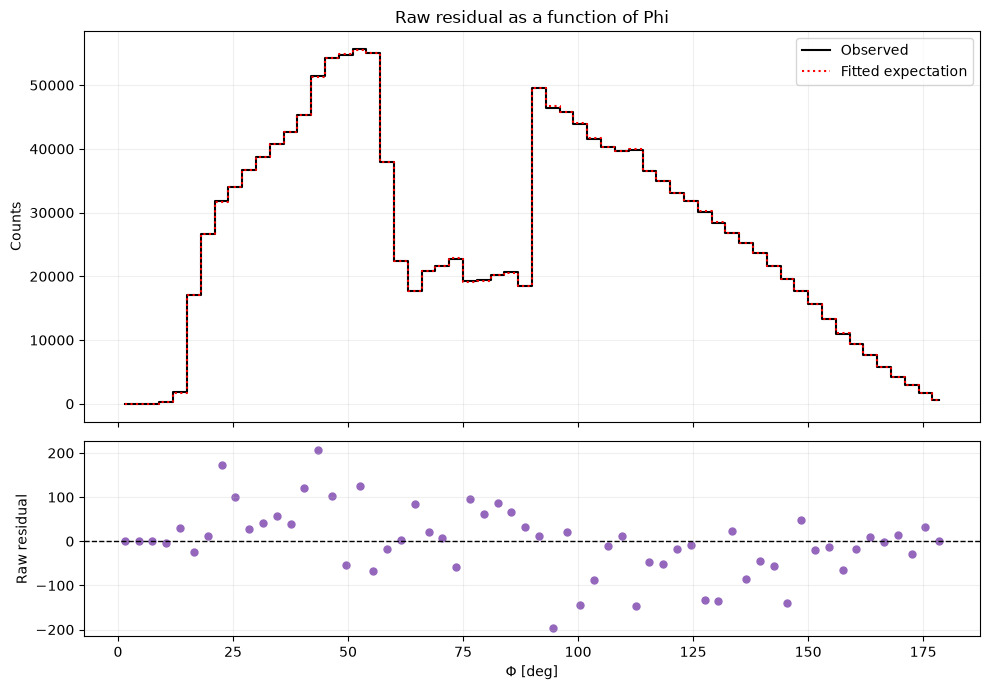

In [26]:
# Plot observed and expected counts with the raw residual in Phi.
plot_raw_residual_projection(
    coordinates=phi_centers,
    observed=phi_observed,
    expected=phi_expected,
    residual=phi_residual,
    x_label=r"$\Phi$ [deg]",
    title="Raw residual as a function of Phi",
)

**Plot: Psi & Chi projections**

In [27]:
# Extract the matched observed and expected coordinate views.
chi_observed = chi_products["observed"]
chi_expected = chi_products["expected"]
psi_observed = psi_products["observed"]
psi_expected = psi_products["expected"]

# Calculate raw residuals after the coordinate separation.
chi_raw_residual = chi_observed - chi_expected
psi_raw_residual = psi_observed - psi_expected

print("Chi residual shape:", chi_raw_residual.shape)
print("Psi residual shape:", psi_raw_residual.shape)

Chi residual shape: (72,)
Psi residual shape: (36,)


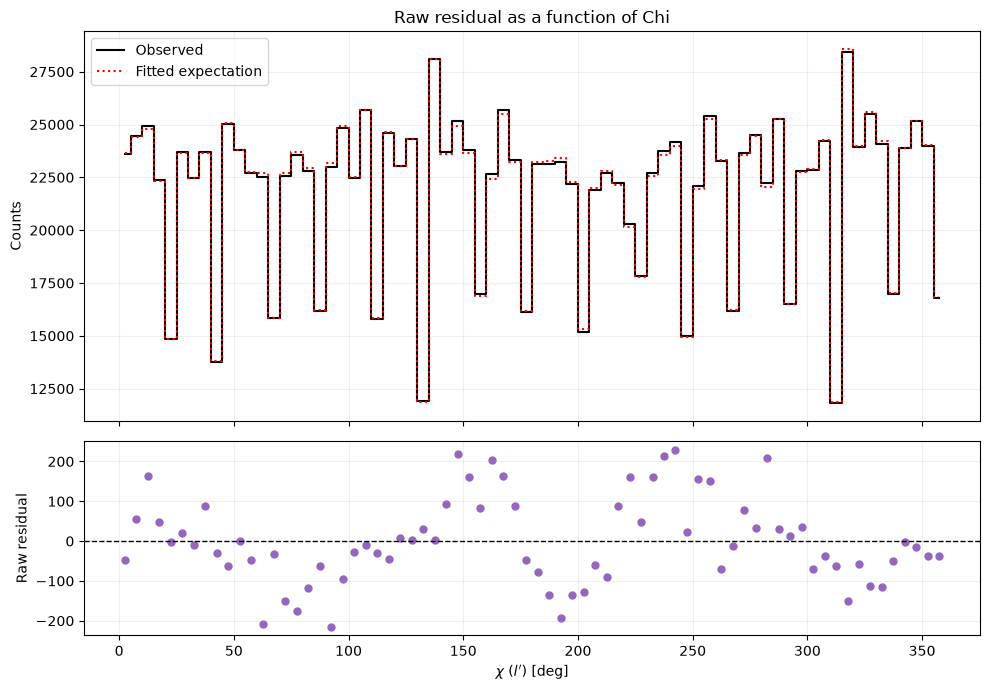

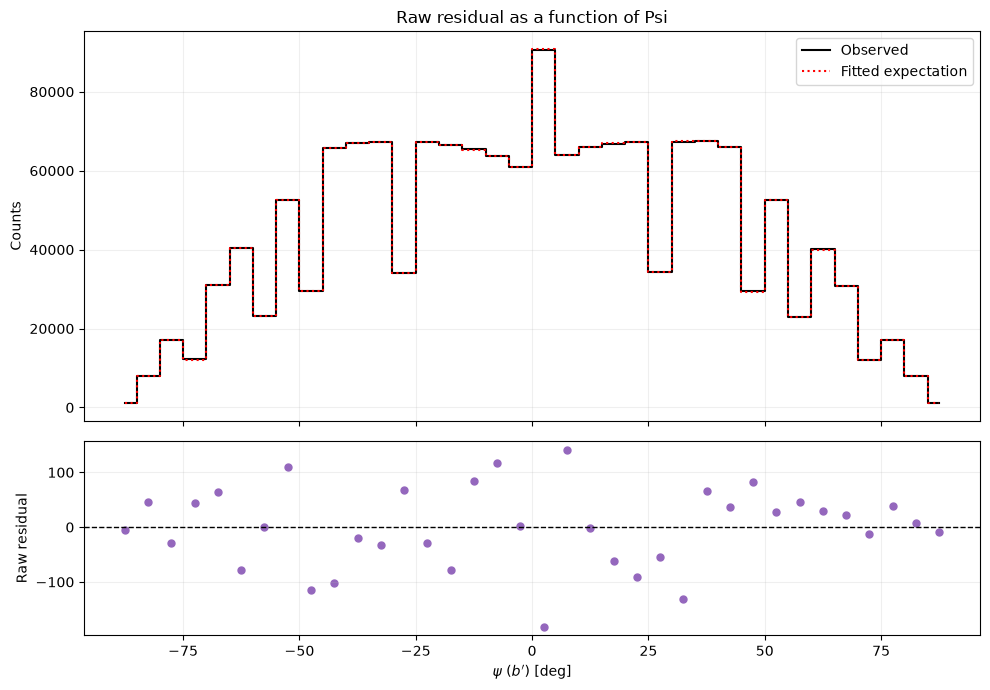

In [28]:
# Plot the raw residual projection in Chi.
plot_raw_residual_projection(
    chi_bin_centers,
    chi_observed,
    chi_expected,
    chi_raw_residual,
    r"$\chi$ ($l'$) [deg]",
    "Raw residual as a function of Chi",
)

# Plot the raw residual projection in Psi.
plot_raw_residual_projection(
    psi_bin_centers,
    psi_observed,
    psi_expected,
    psi_raw_residual,
    r"$\psi$ ($b'$) [deg]",
    "Raw residual as a function of Psi",
)

***
## Multidimensional raw residual views



**PsiChi residual map**

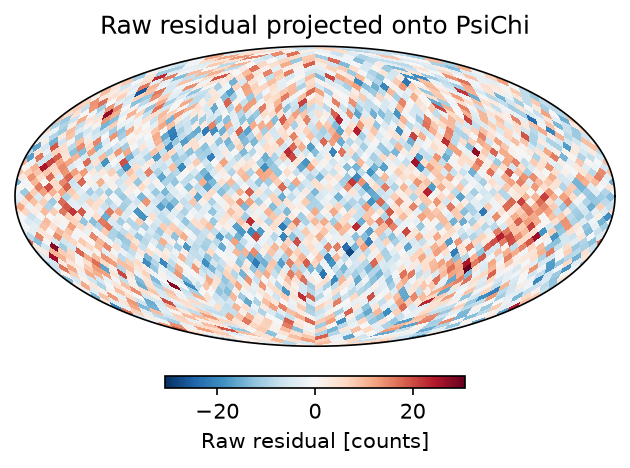

In [30]:
# Extract the existing PsiChi raw-residual projection.
psichi_residual = np.asarray(
    raw_residual_views["psichi"].contents,
    dtype=float,
)

# Use symmetric color limits for the signed raw residual.
residual_limit = np.max(np.abs(psichi_residual))
residual_norm = TwoSlopeNorm(
    vmin=-residual_limit,
    vcenter=0.0,
    vmax=residual_limit,
)

# Build the map using the original PsiChi HEALPix geometry.
psichi_residual_map = mhp.HealpixMap(
    data=psichi_residual,
    nside=psichi_axis.nside,
    scheme=psichi_axis.scheme,
    coordsys=psichi_axis.coordsys,
)

# Plot the residual across the scattered-photon directions.
map_image, map_axis = psichi_residual_map.plot(
    "mollview",
    cmap="RdBu_r",
    norm=residual_norm,
)

map_image.colorbar.set_label("Raw residual [counts]")
map_axis.set_title("Raw residual projected onto PsiChi")
plt.show()

**Phi-Chi & Phi-Psi residuals**

In [36]:
# Calculate the two-dimensional raw residuals.
phi_chi_raw_residual = (
    phi_chi_products["observed"]
    - phi_chi_products["expected"]
)

phi_psi_raw_residual = (
    phi_psi_products["observed"]
    - phi_psi_products["expected"]
)

print(
    "Phi-Chi residual shape:",
    phi_chi_raw_residual.shape,
)

print(
    "Phi-Psi residual shape:",
    phi_psi_raw_residual.shape,
)

Phi-Chi residual shape: (60, 72)
Phi-Psi residual shape: (60, 36)


In [38]:
# Extract the original Phi bin edges in degrees.
phi_edges = phi_axis.edges.to_value(u.deg)

# Use one symmetric color scale for both residual views.
multidimensional_residual_limit = max(
    np.max(np.abs(phi_chi_raw_residual)),
    np.max(np.abs(phi_psi_raw_residual)),
)

multidimensional_residual_norm = TwoSlopeNorm(
    vmin=-multidimensional_residual_limit,
    vcenter=0.0,
    vmax=multidimensional_residual_limit,
)

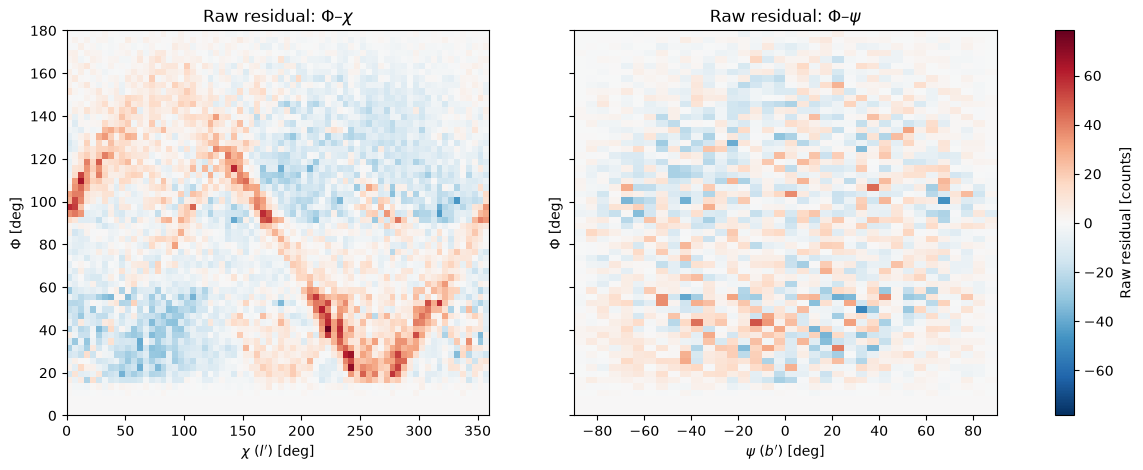

In [39]:


figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5),
    sharey=True,
)

phi_chi_image = plot_raw_residual_heatmap(
    axis=axes[0],
    x_edges=chi_edges,
    y_edges=phi_edges,
    residual=phi_chi_raw_residual,
    x_label=r"$\chi$ ($l'$) [deg]",
    y_label=r"$\Phi$ [deg]",
    title=r"Raw residual: $\Phi$–$\chi$",
    color_norm=multidimensional_residual_norm,
)

phi_psi_image = plot_raw_residual_heatmap(
    axis=axes[1],
    x_edges=psi_edges,
    y_edges=phi_edges,
    residual=phi_psi_raw_residual,
    x_label=r"$\psi$ ($b'$) [deg]",
    y_label=r"$\Phi$ [deg]",
    title=r"Raw residual: $\Phi$–$\psi$",
    color_norm=multidimensional_residual_norm,
)

figure.colorbar(
    phi_psi_image,
    ax=axes,
    label="Raw residual [counts]",
)

plt.show()